In [1]:
import os
import matplotlib as mpl
import numpy as np
import pandas as pd
import scanpy as sc
#import celltypist
#from celltypist import models
import scvi
import gc

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80, facecolor='white', color_map='viridis')
sc.logging.print_header()

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/conda/envs/autoimmune/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.9.8 anndata==0.10.5.post1 umap==0.5.5 numpy==1.26.4 scipy==1.12.0 pandas==1.5.3 scikit-learn==1.4.1.post1 statsmodels==0.14.1 igraph==0.11.4 pynndescent==0.5.11


In [2]:
import scarches as sca
#from scarches.dataset.trvae.data_handling import remove_sparsity

 captum (see https://github.com/pytorch/captum).


In [3]:
import torch

In [4]:
import gdown
#import scarches as sca
#from scarches.dataset.trvae.data_handling import remove_sparsity

In [5]:
torch.set_printoptions(precision=3, sci_mode=False, edgeitems=7)

In [6]:
print(sc.__version__)

1.9.8


In [7]:
print(scvi.__version__)

1.1.1


In [8]:
#dir_save="/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/"
#path='/nfs/team205/bh14/Datasets/Remapped/raw_adata/QC_concatenated/'

In [9]:
#adata = sc.read_h5ad('Immune_compartment_QC_filtered_2.h5ad')

In [10]:
#del adata

In [11]:
def load_sub_adata(adata, obs_file):
    obs = pd.read_csv(obs_file, index_col=0)
    if "scvi_clusters" in obs.columns:
        obs.drop(columns="scvi_clusters", inplace=True)
    temp = adata[obs.index].copy()
    temp.obs = obs
    return temp

In [12]:
def load_model(adata, save_path, obs_file_path):
    
    adata_hvg = load_sub_adata(adata=adata, obs_file=obs_file_path)
    
    print("running hvg")

    sc.pp.highly_variable_genes(
        adata_hvg, 
        flavor="seurat_v3", 
        n_top_genes=2000, 
        layer="counts", 
        batch_key="batch",
        subset=True
    )
                               
    print("loading model .....")
    
    vae = scvi.model.SCVI.load(save_path, adata=adata_hvg, use_gpu=True)
    vae.get_latent_representation()
    
    return vae

In [13]:
dir_save="./Subset_2023/"
#path='/nfs/team205/bh14/Datasets/Remapped/raw_adata/ummapped/Tissue/QC_Doublet_concat/'

## load query

In [14]:
haniffaAd = sc.read_h5ad('haniffalab_QC.h5ad')

In [15]:
haniffaAd

AnnData object with n_obs × n_vars = 210443 × 33538
    obs: 'disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue', 'dataset_id', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes'
    var: 'gene_ids-SKN8090524', 'feature_types-SKN8090524', 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p'
    layers: 'counts'

In [16]:
print(haniffaAd.X[100:200])

  (0, 27)	2.838228940963745
  (0, 38)	2.838228940963745
  (0, 55)	2.838228940963745
  (0, 104)	2.838228940963745
  (0, 154)	2.838228940963745
  (0, 178)	2.838228940963745
  (0, 190)	2.838228940963745
  (0, 451)	2.838228940963745
  (0, 491)	2.838228940963745
  (0, 493)	3.3751940727233887
  (0, 504)	2.838228940963745
  (0, 555)	2.838228940963745
  (0, 559)	2.838228940963745
  (0, 584)	2.838228940963745
  (0, 704)	2.838228940963745
  (0, 733)	2.838228940963745
  (0, 865)	3.0750572681427
  (0, 875)	2.838228940963745
  (0, 888)	2.838228940963745
  (0, 904)	2.838228940963745
  (0, 918)	3.1951661109924316
  (0, 935)	3.1951661109924316
  (0, 1045)	2.838228940963745
  (0, 1259)	2.838228940963745
  (0, 1297)	2.838228940963745
  :	:
  (99, 32753)	2.54604172706604
  (99, 32767)	2.642083168029785
  (99, 32795)	1.8231158256530762
  (99, 32829)	2.54604172706604
  (99, 32883)	1.8231158256530762
  (99, 32976)	2.642083168029785
  (99, 32977)	2.210798501968384
  (99, 32978)	1.8231158256530762
  (99, 3324

In [17]:
#haniffaAd.obs.columns
haniffaAd.obs.cell_type.value_counts()

Th                    55168
nan                   34175
Tc                    15952
Treg                  13071
Inf_mono               7970
moDC_1                 7464
Macro_1                7179
Mono                   7131
LC_3                   6231
LC_4                   5897
moDC_2                 5534
Pericyte_2_inflamm     5253
DC2                    5113
LE2                    5091
LC_2                   4747
MigDC                  4408
ILC1_3                 3932
moDC_3                 3815
ILC1_NK                3323
Macro_2                2710
DC1                    1936
LC_1                   1812
Mast_cell               897
NK                      886
ILC2                    666
Plasma                   82
Name: cell_type, dtype: int64

In [18]:
keep_cells = ['Th', 'Tc', 'Treg', 'ILC1_3', 'ILC1_NK', 'NK', 'ILC2']

In [19]:
keep_cells

['Th', 'Tc', 'Treg', 'ILC1_3', 'ILC1_NK', 'NK', 'ILC2']

In [20]:
haniffaAd = haniffaAd[haniffaAd.obs.cell_type.isin(keep_cells)]

In [21]:
haniffaAd.var = haniffaAd.var[['gene_ids-SKN8090524', 'feature_types-SKN8090524']]

In [22]:
#haniffaAd.obs["tissue"] = haniffaAd.obs.Tissue
haniffaAd.obs["dataset_id"] = "Skin_Reynolds_et_al"

In [23]:
haniffaAd.obs.columns

Index(['disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location',
       'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue',
       'dataset_id', 'doublet_scores', 'predicted_doublets',
       'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes'],
      dtype='object')

In [24]:
haniffaAd.obs.cell_type.value_counts()

Th         55168
Tc         15952
Treg       13071
ILC1_3      3932
ILC1_NK     3323
NK           886
ILC2         666
Name: cell_type, dtype: int64

In [25]:
#haniffaAd = haniffaAd[~haniffaAd.obs.cell_type.isin(["LE2", "Th", "Tc", "ILC1_3", "Treg", "Plasma", "ILC1_NK", "NK"])]

In [26]:
#haniffaAd.obs.columns = ['disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 
 #                        'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue', 'dataset_id']

In [27]:
adata_Braga = sc.read_h5ad("Braga_asthma_lung_celltypist.h5ad")

In [28]:
adata_Braga.obs.main_predicted_cell_groups.value_counts()

Multiciliated (non-nasal)    33032
Suprabasal                   22014
Basal resting                12363
CD8 T cells                   7264
CD4 T cells                   4595
Club (non-nasal)              4052
EC venous systemic            3208
DC2                           1700
Classical monocytes           1671
Peribronchial fibroblasts     1182
B cells                        802
Mast cells                     793
Plasma cells                   558
Goblet (bronchial)             508
Goblet (nasal)                 465
Smooth muscle                  415
NK cells                       371
SMG duct                       313
Ionocyte                       279
SMG serous (bronchial)         270
Non-classical monocytes        240
EC arterial                    224
SMG mucous                     184
Alveolar macrophages           133
Plasmacytoid DCs               126
Lymphatic EC mature             41
Name: main_predicted_cell_groups, dtype: int64

In [29]:
adata_Braga = adata_Braga[adata_Braga.obs.main_predicted_cell_groups.isin(['CD8 T cells', 'CD4 T cells', 'NK cells'])].copy()

In [30]:
adata_query = adata_Braga.concatenate(haniffaAd, batch_key="ref_query")

/var/tmp/ipykernel_120899/1405389183.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_query = adata_Braga.concatenate(haniffaAd, batch_key="ref_query")


In [31]:
del haniffaAd
del adata_Braga
adata_query

AnnData object with n_obs × n_vars = 105228 × 31915
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'main_predicted_cell_groups', 'leiden', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 'development_stage', 'cell_type', 'ref_query'
    var: 'gene_ids-SKN8090524-1', 'feature_types-SKN8090524-1'
    layers: 'counts'

In [32]:
adata_query[adata_query.obs.cell_type.isna()].obs.dataset_id.value_counts()

Braga_asthma    12230
Name: dataset_id, dtype: int64

In [33]:
adata_query=adata_query[~(adata_query.obs.cell_type.isna() & adata_query.obs.dataset_id.isin(["Skin_Reynolds_et_al"]))]

## load reference

In [34]:
adata_ref = sc.read_h5ad("T_Cell_From_Tissue_label_transfert_Subset_annotated_Milo_3K.h5ad")

In [35]:
adata_ref.obs.Cell_type_scANVI.value_counts()

Tem/Trm cytotoxic              25831
Trm cytotoxic                  24807
Th17                           19936
Tem/Eff helper T               19195
T regs                         15089
Th1                            14476
Tcm/Naive helper T             13136
T follicular helper            13106
γδ T cells                      8625
NK_CD56bright                   6394
Trm_gut                         5944
MAIT cell                       5659
Trm_γδ                          4631
Tcm/Naive cytotoxic T cells     4539
Th1/Th17_gut                    4059
ILC3                            3489
Tem/Trm cytotoxic_Syn-Fluid     3477
CD8_ZNF683+                     3155
TCD4_CM/T_Naive_Syn-Fluid       2900
Cycl Treg                       2532
PD1 CD4 T cells                 1817
Trm cytotoxic INFGhi            1647
CD4                             1537
NK_CD16hi                       1252
Cycl CD8                        1039
Cycl NK                          764
Name: Cell_type_scANVI, dtype: int64

In [36]:
commonGen = [gen for gen in adata_query.var_names if gen in adata_ref.var_names]

In [37]:
commonGen[:10]

['FAM87B',
 'LINC00115',
 'SAMD11',
 'NOC2L',
 'KLHL17',
 'PLEKHN1',
 'HES4',
 'ISG15',
 'AGRN',
 'RNF223']

In [38]:
adata_ref = adata_ref[:, commonGen]

In [39]:
adata_ref

View of AnnData object with n_obs × n_vars = 209036 × 17209
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'batch', 'orig.ident', 'Site', 'n_genes', 'leiden_1_5', 'predicted_labels', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'author_annotation', 'leiden_man', 'leiden_R', 'cell_type2', 'majority_voting_2', 'leiden', 'Cell_type_scANVI', 'over_clustering', 'leiden_2', 'leiden_3', 'relabeled_cells', 'relabeled_cells_2', 'relabeled_cells_3', 'tissue_harmo', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-

#### Analyze reference and query

In [40]:
adata_ref

View of AnnData object with n_obs × n_vars = 209036 × 17209
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'batch', 'orig.ident', 'Site', 'n_genes', 'leiden_1_5', 'predicted_labels', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'author_annotation', 'leiden_man', 'leiden_R', 'cell_type2', 'majority_voting_2', 'leiden', 'Cell_type_scANVI', 'over_clustering', 'leiden_2', 'leiden_3', 'relabeled_cells', 'relabeled_cells_2', 'relabeled_cells_3', 'tissue_harmo', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


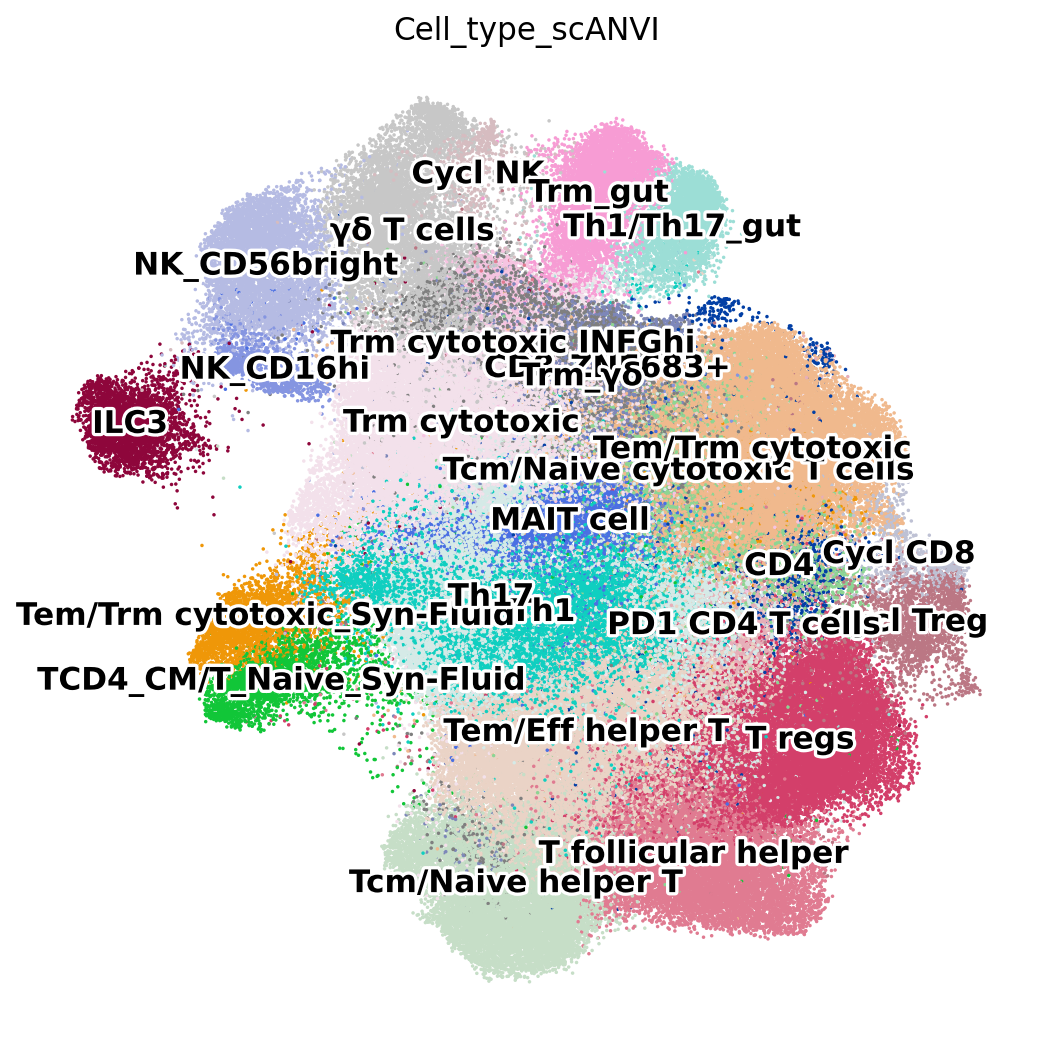

In [41]:
sc.set_figure_params(figsize=(8,8))
sc.pl.umap(
    adata_ref,
    color=['Cell_type_scANVI'],
    ncols=2,
    frameon=False,
    size=10,
    legend_fontoutline=3,
    legend_loc='on data'
)

In [42]:
sc.pp.highly_variable_genes(
    adata_ref,
    n_top_genes=2000,
    batch_key="dataset_id",
    subset=True)

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:31)


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:553: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [43]:
adata_ref

AnnData object with n_obs × n_vars = 209036 × 2000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'batch', 'orig.ident', 'Site', 'n_genes', 'leiden_1_5', 'predicted_labels', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'author_annotation', 'leiden_man', 'leiden_R', 'cell_type2', 'majority_voting_2', 'leiden', 'Cell_type_scANVI', 'over_clustering', 'leiden_2', 'leiden_3', 'relabeled_cells', 'relabeled_cells_2', 'relabeled_cells_3', 'tissue_harmo', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pc

In [44]:
adata_ref.X = adata_ref.raw[:, adata_ref.var_names].X

In [45]:
adata_query = adata_query[:, adata_ref.var_names]

In [46]:
adata_ref

AnnData object with n_obs × n_vars = 209036 × 2000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'batch', 'orig.ident', 'Site', 'n_genes', 'leiden_1_5', 'predicted_labels', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'author_annotation', 'leiden_man', 'leiden_R', 'cell_type2', 'majority_voting_2', 'leiden', 'Cell_type_scANVI', 'over_clustering', 'leiden_2', 'leiden_3', 'relabeled_cells', 'relabeled_cells_2', 'relabeled_cells_3', 'tissue_harmo', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pc

## SCVI model

In [47]:
sca.models.SCVI.setup_anndata(adata_ref,  batch_key="donor_id", labels_key="Cell_type_scANVI")

/opt/conda/envs/autoimmune/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [48]:
vae = sca.models.SCVI(
    adata_ref,
    n_layers=2,
    encode_covariates=True,
    deeply_inject_covariates=False,
    use_layer_norm="both",
    use_batch_norm="none",
)

In [49]:
early_stopping_kwargs = {
    #"early_stopping_metric": "elbo",
    "save_best_state_metric": "elbo",
    "patience": 10,
    "threshold": 0,
    "reduce_lr_on_plateau": True,
    "lr_patience": 8,
    "lr_factor": 0.1,
}
vae.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/38:   0%|          | 0/38 [00:00<?, ?it/s]

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/module/_vae.py:458: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/module/_vae.py:458: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


Epoch 2/38:   3%|▎         | 1/38 [00:17<11:04, 17.96s/it, v_num=1, train_loss_step=510, train_loss_epoch=530]

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/module/_vae.py:458: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/module/_vae.py:458: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


...

Epoch 38/38:  97%|█████████▋| 37/38 [10:55<00:18, 18.27s/it, v_num=1, train_loss_step=479, train_loss_epoch=464]

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/module/_vae.py:458: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/module/_vae.py:458: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


Epoch 38/38: 100%|██████████| 38/38 [11:13<00:00, 18.26s/it, v_num=1, train_loss_step=460, train_loss_epoch=464]

`Trainer.fit` stopped: `max_epochs=38` reached.


Epoch 38/38: 100%|██████████| 38/38 [11:13<00:00, 17.72s/it, v_num=1, train_loss_step=460, train_loss_epoch=464]


In [50]:
adata_ref.obsm["X_scVI2"] = vae.get_latent_representation()

In [51]:
sc.pp.neighbors(adata_ref, use_rep="X_scVI2", n_neighbors=60)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:53)


In [52]:
sc.tl.leiden(adata_ref)

running Leiden clustering
    finished: found 16 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:08:22)


In [53]:
sc.tl.umap(adata_ref, min_dist=0.5, spread=1)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:05:32)


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


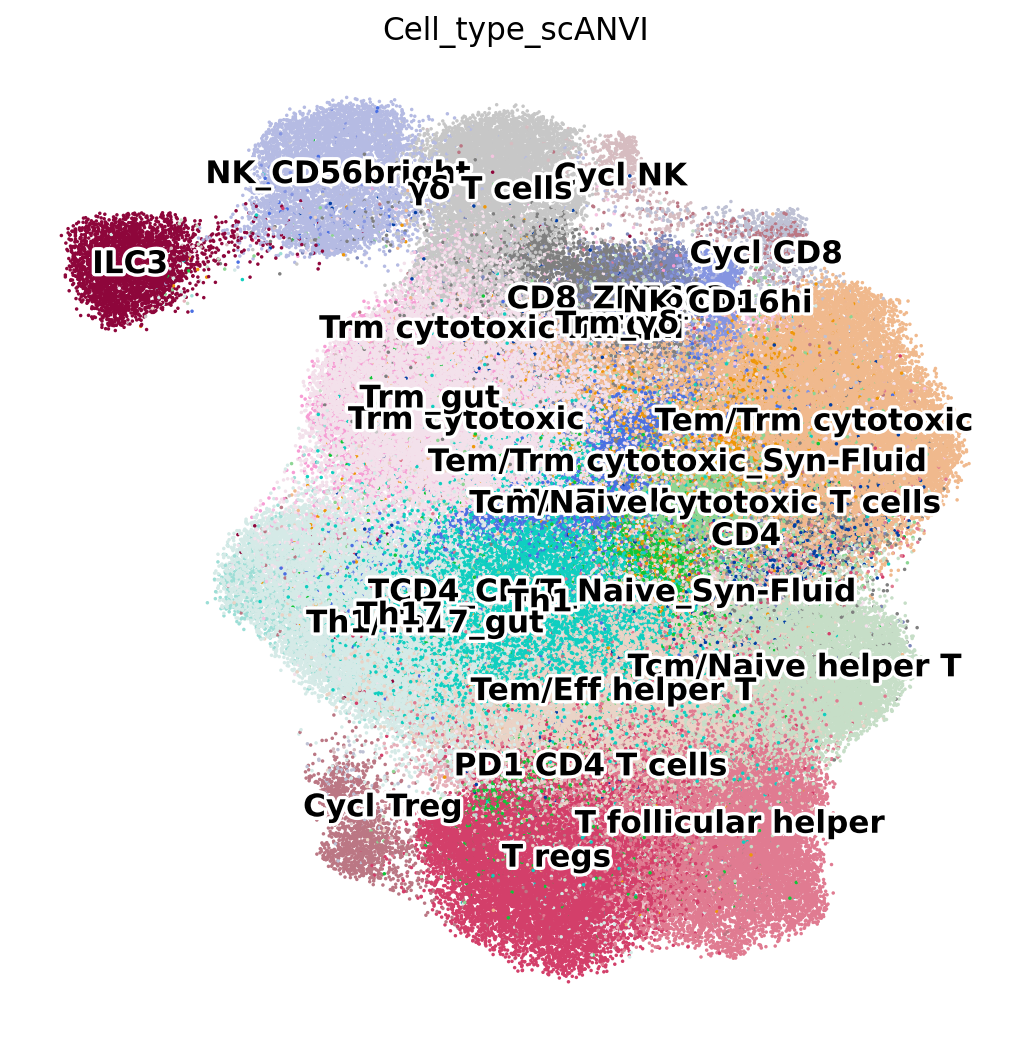

In [54]:
sc.set_figure_params(figsize=(8,8))
sc.pl.umap(
    adata_ref,
    color=['Cell_type_scANVI'],
    ncols=2,
    frameon=False,
    size=10,
    legend_fontoutline=3,
    legend_loc='on data'
)

In [56]:
save_path="Model_2024/ref_model_tissue_T_cells_scvi_2024/"


In [57]:
adata_query.obs.cell_type.value_counts()

Th         55168
Tc         15952
Treg       13071
ILC1_3      3932
ILC1_NK     3323
NK           886
ILC2         666
Name: cell_type, dtype: int64

In [58]:
#ref_path = 'ref_model_tissue_for_asthma_and_skin'
#scanvae.save(ref_path+"_scanvi", overwrite=True)
vae.save(save_path, overwrite=True, save_anndata=True)

In [59]:
scvi.model.SCVI.prepare_query_anndata(adata=adata_ref, reference_model=save_path)

INFO     File Model_2024/ref_model_tissue_T_cells_scvi_2024/model.pt already downloaded                            
INFO     Found 100.0% reference vars in query data.                                                                


In [60]:
vae_ref = scvi.model.SCVI.load_query_data(reference_model=save_path, adata=adata_ref)

INFO     File Model_2024/ref_model_tissue_T_cells_scvi_2024/model.pt already downloaded                            


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [61]:
adata_ref

AnnData object with n_obs × n_vars = 209036 × 2000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'batch', 'orig.ident', 'Site', 'n_genes', 'leiden_1_5', 'predicted_labels', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'author_annotation', 'leiden_man', 'leiden_R', 'cell_type2', 'majority_voting_2', 'leiden', 'Cell_type_scANVI', 'over_clustering', 'leiden_2', 'leiden_3', 'relabeled_cells', 'relabeled_cells_2', 'relabeled_cells_3', 'tissue_harmo', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pc

In [62]:
# unlabeled category does not exist in adata.obs[labels_key]
# so all cells are treated as labeled
vae_ref_scan = scvi.model.SCANVI.from_scvi_model(
    vae,
    unlabeled_category="Unknown",
    labels_key="Cell_type_scANVI",
)

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [63]:
vae_ref_scan.train(max_epochs=50, n_samples_per_label=100)

INFO     Training for 50 epochs.                                                                                   


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/50:   0%|          | 0/50 [00:00<?, ?it/s]

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/module/_scanvae.py:304: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/module/_scanvae.py:304: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)


Epoch 2/50:   2%|▏         | 1/50 [00:39<32:01, 39.22s/it, v_num=1, train_loss_step=466, train_loss_epoch=474]

...

Epoch 50/50:  98%|█████████▊| 49/50 [31:48<00:38, 38.24s/it, v_num=1, train_loss_step=463, train_loss_epoch=461]

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/module/_scanvae.py:304: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/module/_scanvae.py:304: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)


Epoch 50/50: 100%|██████████| 50/50 [32:27<00:00, 38.41s/it, v_num=1, train_loss_step=450, train_loss_epoch=461]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [32:27<00:00, 38.95s/it, v_num=1, train_loss_step=450, train_loss_epoch=461]


In [64]:
adata_ref.obsm["X_scANVI"] = vae_ref_scan.get_latent_representation()

In [65]:
sc.pp.neighbors(adata_ref, use_rep="X_scANVI", n_neighbors=60)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:33)


In [66]:
#sc.tl.leiden(adata_ref)

In [67]:
sc.tl.umap(adata_ref, min_dist=0.5, spread=1)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:05:37)


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


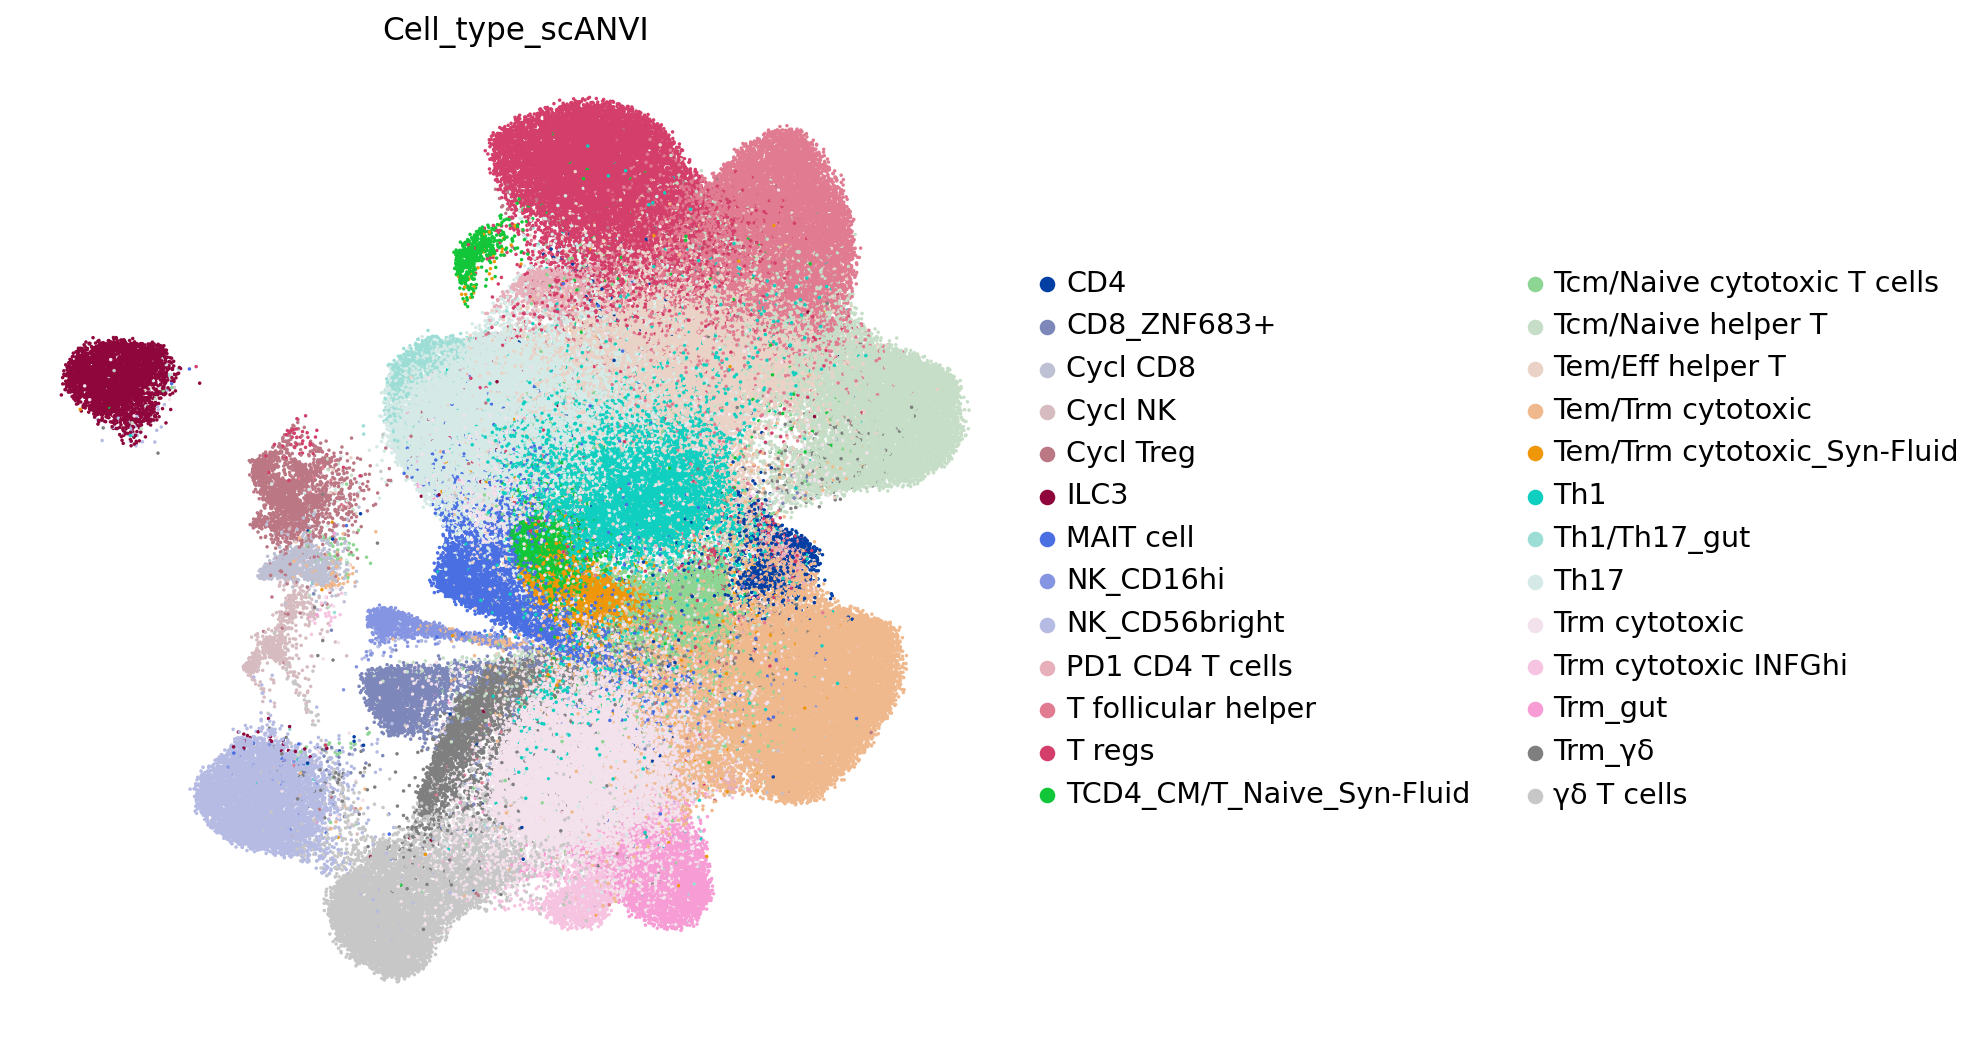

In [68]:
sc.pl.umap(
    adata_ref,
    color=["Cell_type_scANVI"],
    frameon=False,
    ncols=1,
    size=10

)

In [69]:
adata_ref

AnnData object with n_obs × n_vars = 209036 × 2000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'batch', 'orig.ident', 'Site', 'n_genes', 'leiden_1_5', 'predicted_labels', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'author_annotation', 'leiden_man', 'leiden_R', 'cell_type2', 'majority_voting_2', 'leiden', 'Cell_type_scANVI', 'over_clustering', 'leiden_2', 'leiden_3', 'relabeled_cells', 'relabeled_cells_2', 'relabeled_cells_3', 'tissue_harmo', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pc

In [70]:
dir_path_scan = "Model_2024/scvi_model_T_cells_From_Tissue_Subset_5_model_scanvi_2024/"
vae_ref_scan.save(dir_path_scan, overwrite=True, save_anndata=True)


In [71]:
scvi.model.SCVI.prepare_query_anndata(adata=adata_query, reference_model=dir_path_scan)

INFO     File Model_2024/scvi_model_T_cells_From_Tissue_Subset_5_model_scanvi_2024/model.pt already downloaded     
INFO     Found 100.0% reference vars in query data.                                                                


In [72]:
adata_query

View of AnnData object with n_obs × n_vars = 105228 × 2000
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'main_predicted_cell_groups', 'leiden', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 'development_stage', 'cell_type', 'ref_query'
    var: 'gene_ids-SKN8090524-1', 'feature_types-SKN8090524-1'
    layers: 'counts'

In [73]:
adata_query = adata_query.copy()

In [74]:
vae_q = scvi.model.SCANVI.load_query_data(
    adata_query,
    dir_path_scan,
    
)

INFO     File Model_2024/scvi_model_T_cells_From_Tissue_Subset_5_model_scanvi_2024/model.pt already downloaded     


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/data/_manager.py:209: UserWarning: Missing labels key Cell_type_scANVI. Filling in with unlabeled category Unknown.
  field_registry[_constants._STATE_REGISTRY_KEY] = field.transfer_field(


In [75]:
vae_q._unlabeled_indices = np.arange(adata_query.n_obs)
vae_q._labeled_indices = []

In [76]:
vae_q.train(
    max_epochs=80,
    plan_kwargs=dict(weight_decay=0.0),
    check_val_every_n_epoch=10,
)

INFO     Training for 80 epochs.                                                                                   


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/80:   0%|          | 0/80 [00:00<?, ?it/s]

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/module/_scanvae.py:304: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/module/_scanvae.py:304: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)


Epoch 2/80:   1%|▏         | 1/80 [00:15<20:02, 15.22s/it, v_num=1, train_loss_step=515, train_loss_epoch=534]

...

Epoch 80/80:  99%|█████████▉| 79/80 [19:25<00:14, 14.17s/it, v_num=1, train_loss_step=528, train_loss_epoch=528]

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/module/_scanvae.py:304: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/module/_scanvae.py:304: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)


Epoch 80/80: 100%|██████████| 80/80 [19:40<00:00, 14.37s/it, v_num=1, train_loss_step=538, train_loss_epoch=528]

`Trainer.fit` stopped: `max_epochs=80` reached.


Epoch 80/80: 100%|██████████| 80/80 [19:40<00:00, 14.75s/it, v_num=1, train_loss_step=538, train_loss_epoch=528]


In [77]:
adata_query.obsm["X_scANVI"] = vae_q.get_latent_representation()

In [78]:
dir_path_scan_query = "Model_2024/scvi_model_T_cells_From_Tissue_Subset_5_model_scanvi_for_quering_2024/"
vae_q.save(dir_path_scan_query , overwrite=True, save_anndata=True)

## Analyze reference and query

In [79]:
adata_full = adata_query.concatenate(adata_ref)

/var/tmp/ipykernel_120899/4106736511.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_full = adata_query.concatenate(adata_ref)


In [80]:
adata_full.obs.batch.cat.rename_categories(["Query", "Reference"], inplace=True)

/var/tmp/ipykernel_120899/1368899537.py:1: FutureWarning: The `inplace` parameter in pandas.Categorical.rename_categories is deprecated and will be removed in a future version. Removing unused categories will always return a new Categorical object.
  adata_full.obs.batch.cat.rename_categories(["Query", "Reference"], inplace=True)


In [81]:
full_predictions = vae_q.predict(adata_full)

adata_full.obs["Cell_type_scANVI2"] = full_predictions

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [82]:
adata_full

AnnData object with n_obs × n_vars = 314264 × 2000
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'main_predicted_cell_groups', 'leiden', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 'development_stage', 'cell_type', 'ref_query', '_scvi_batch', 'Cell_type_scANVI', '_scvi_labels', 'batch', 'orig.ident', 'leiden_1_5', 'barcodes', 'barcode', 'full_clustering', 'log1p_total_counts', 'author_annotation', 'leiden_man', 'leiden_R', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells', 'relabeled_cells_2', 'relabeled_cells_3', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance', 'Cell_type_scANVI2'
    

In [83]:
sc.tl.pca(adata_full, svd_solver='arpack')

computing PCA
    with n_comps=50
    finished (0:00:36)


In [84]:
adata_full

AnnData object with n_obs × n_vars = 314264 × 2000
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'main_predicted_cell_groups', 'leiden', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 'development_stage', 'cell_type', 'ref_query', '_scvi_batch', 'Cell_type_scANVI', '_scvi_labels', 'batch', 'orig.ident', 'leiden_1_5', 'barcodes', 'barcode', 'full_clustering', 'log1p_total_counts', 'author_annotation', 'leiden_man', 'leiden_R', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells', 'relabeled_cells_2', 'relabeled_cells_3', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance', 'Cell_type_scANVI2'
    

In [85]:
sc.pp.neighbors(adata_full, use_rep="X_scANVI", n_neighbors=60, key_added='scanvi_neighbors')

computing neighbors
    finished: added to `.uns['scanvi_neighbors']`
    `.obsp['scanvi_neighbors_distances']`, distances for each pair of neighbors
    `.obsp['scanvi_neighbors_connectivities']`, weighted adjacency matrix (0:02:14)


In [86]:
sc.tl.leiden(adata_full, neighbors_key='scanvi_neighbors')

running Leiden clustering
    finished: found 22 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:17:06)


In [87]:
sc.tl.umap(adata_full, min_dist=0.5, neighbors_key='scanvi_neighbors', spread=1)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:08:36)


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


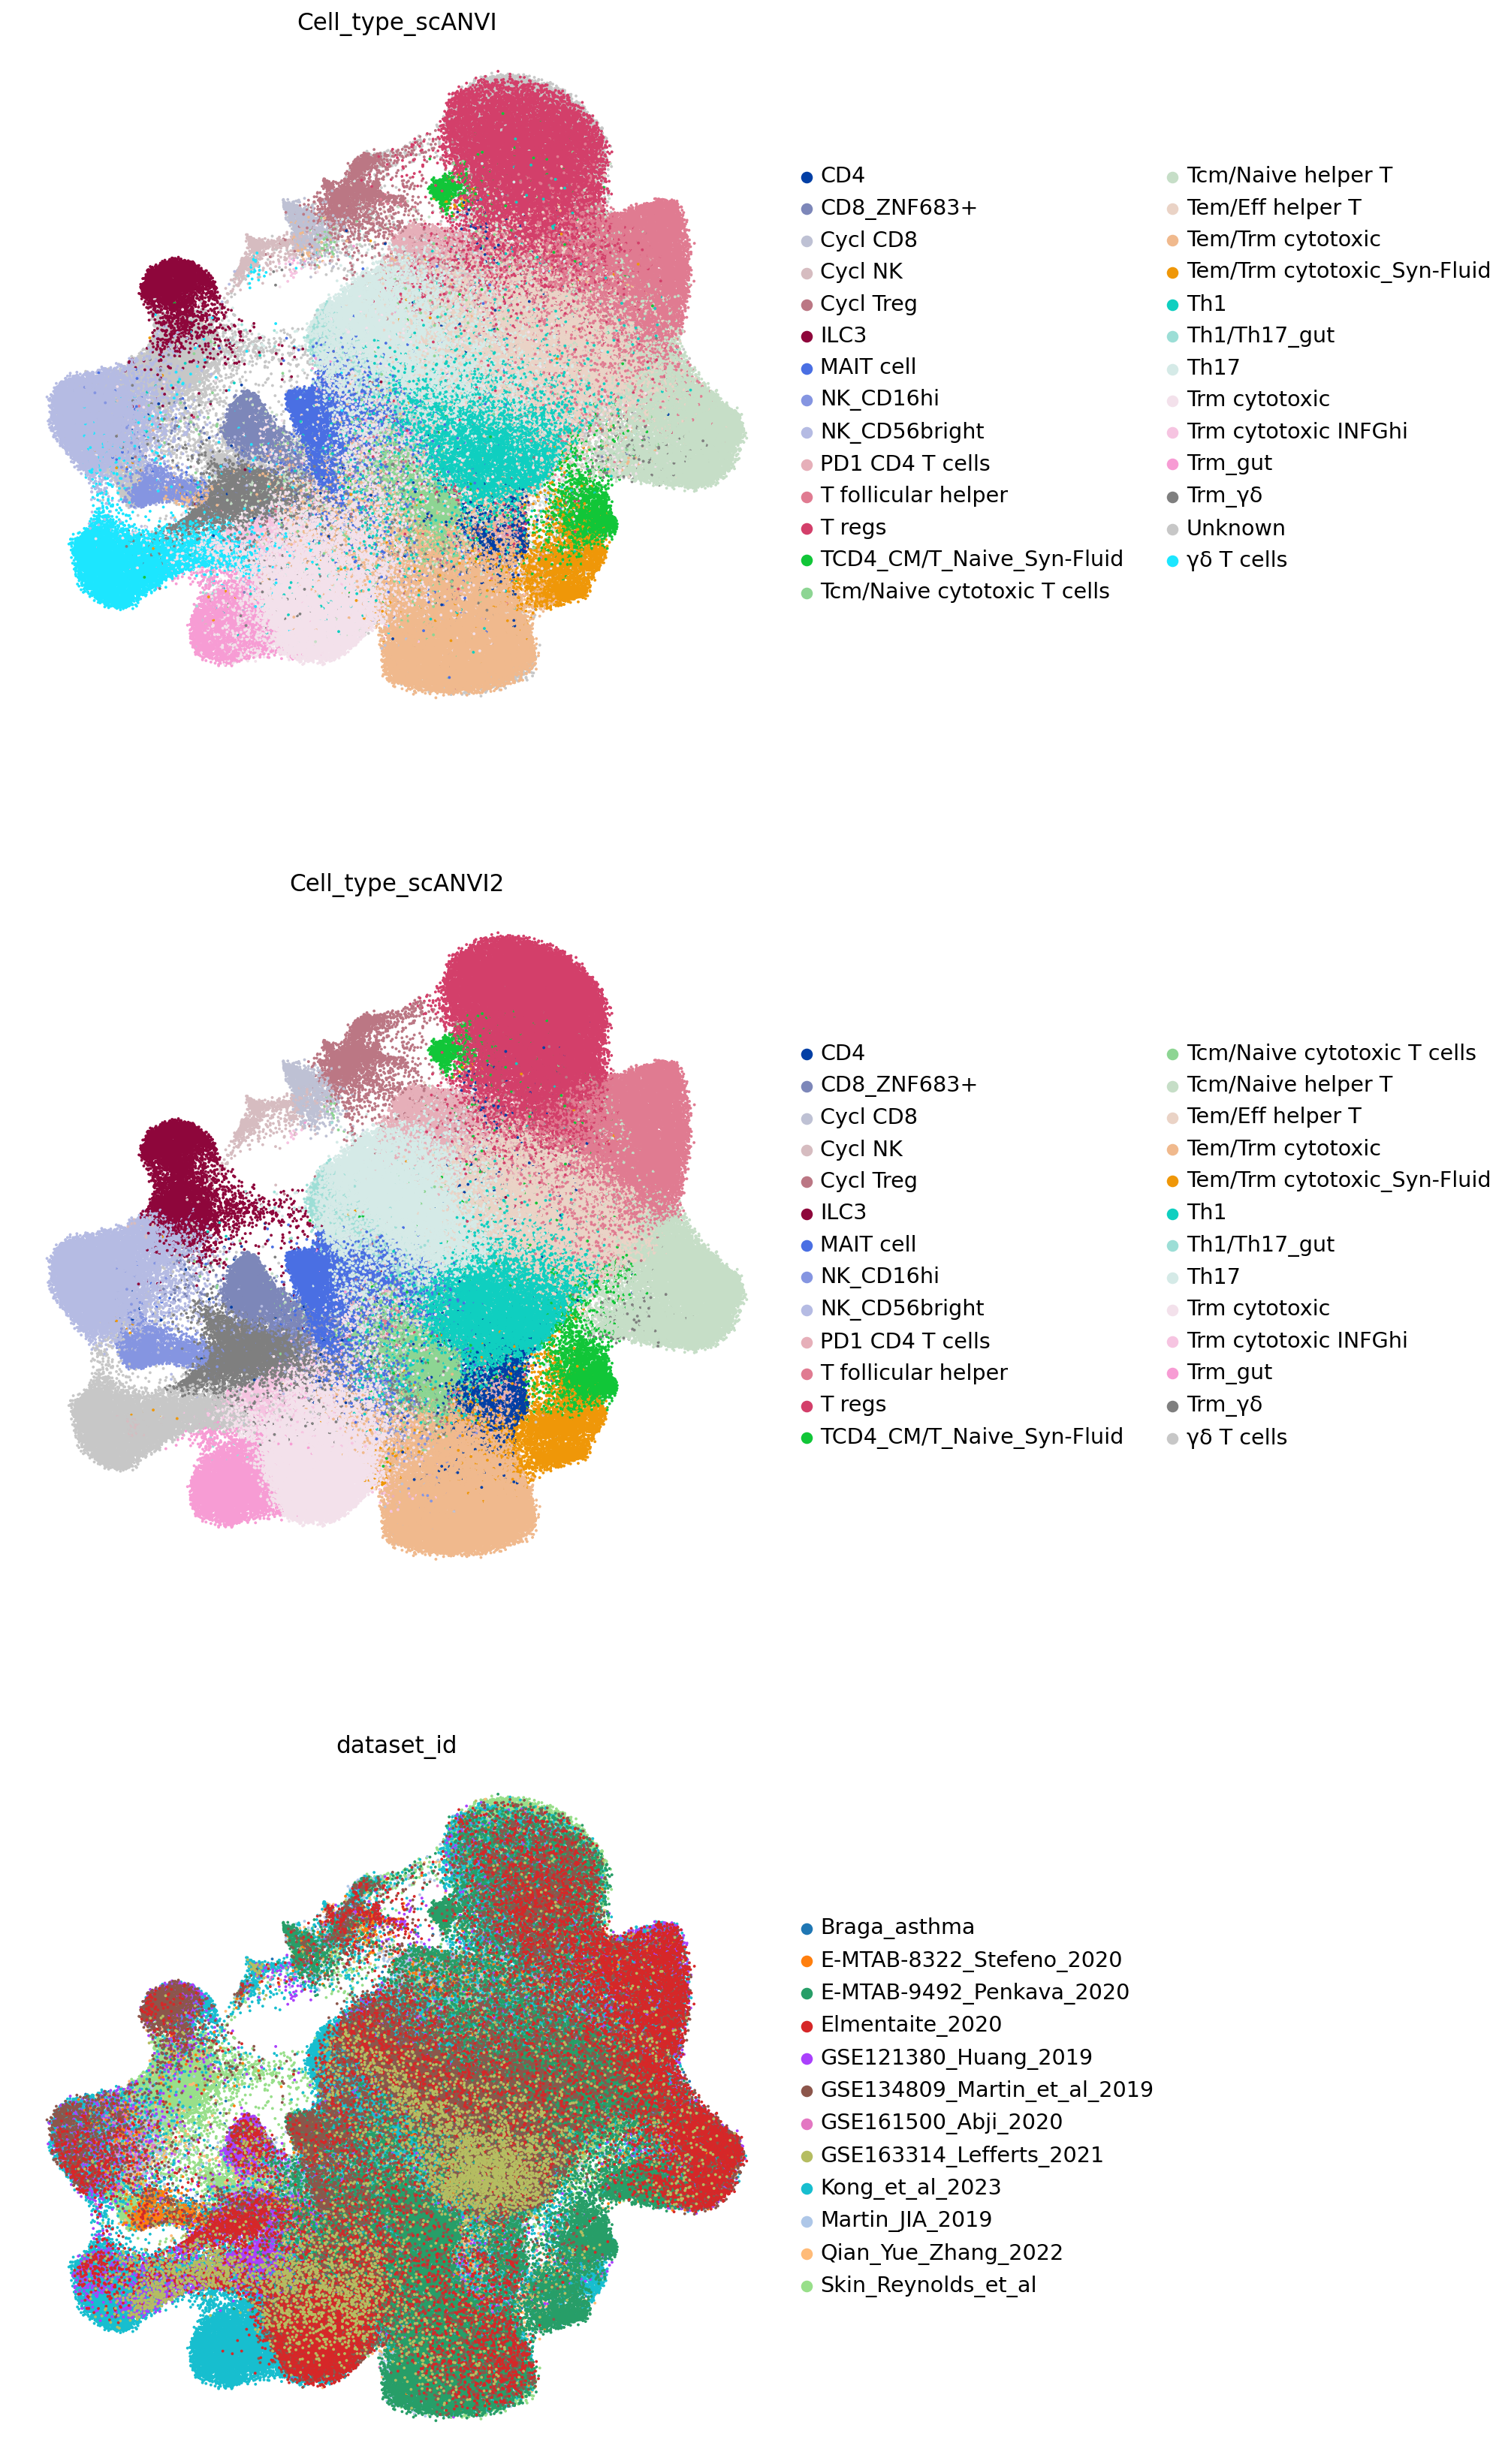

In [88]:
sc.pl.umap(
    adata_full,
    color=["Cell_type_scANVI", "Cell_type_scANVI2", "dataset_id"],
    frameon=False,
    ncols=1,
    size=12
)

In [89]:
adata_full.obs.age = adata_full.obs.age.astype("category")

#### Label transfert

In [90]:
def save_x_scvi(adata,data_dir, file_name, vae):
    """
    data_dir path to save scvi embedding
    file_name name for example Immune_compartment_PBMC
    """
    x_scanvi = vae.get_latent_representation(adata)
    outname = "{fname}.scVI_out.npy".format(fname=file_name)
    modelname = "{fname}_scvi_model".format(fname=file_name)
    np.save(data_dir + outname, x_scanvi)
    vae.save(data_dir + modelname, overwrite=True)
    pd.DataFrame(adata.obs).to_csv(data_dir+outname+".obs.csv")
    np.save(data_dir + file_name+".UMAP.npy", adata.obsm["X_umap"])
    #adata.obs[["leiden"]].to_csv(dir_save + "All_from_Tissue_QC_filtered.clustering_5.csv")


In [91]:
save_x_scvi(adata=adata_full, data_dir="Model_2024/", file_name="scANVI_T_cells_cells_out_with_skin_asthma", vae=vae_q)


In [92]:
#adata_full.obs.over_clustering = adata_full.obs.over_clustering.astype("str")

In [93]:
adata_full

AnnData object with n_obs × n_vars = 314264 × 2000
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'main_predicted_cell_groups', 'leiden', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 'development_stage', 'cell_type', 'ref_query', '_scvi_batch', 'Cell_type_scANVI', '_scvi_labels', 'batch', 'orig.ident', 'leiden_1_5', 'barcodes', 'barcode', 'full_clustering', 'log1p_total_counts', 'author_annotation', 'leiden_man', 'leiden_R', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells', 'relabeled_cells_2', 'relabeled_cells_3', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance', 'Cell_type_scANVI2'
    

In [55]:
##### Get the obs of the full dataset with all common genes

In [56]:
#pd.DataFrame(adata_full.obs).to_csv(dir_save+"scANVI_Myeloid_cells_out_2/Myeloid_cell_from_Tissue_scANVI.obs_2.csv")


In [94]:
adata_full.obs[["leiden"]].to_csv("Model_2024/scANVI_T_cells_cells_out_with_skin_asthma.scVI_out.clustering.csv")


In [96]:
pd.DataFrame(adata_full.obs)

,dataset_id,donor_id,tissue,cell_source,disease,disease_status,age,sex,developmental_stage,sample_id,...,leiden_2,leiden_3,relabeled_cells,relabeled_cells_2,relabeled_cells_3,disease_short,nhood_ixs_random,nhood_ixs_refined,nhood_kth_distance,Cell_type_scANVI2
AACTCTTCAGTCGATT-0-0-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AACTCTTCAGTCGATT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Trm cytotoxic
AAGGAGCCAGTTTACG-0-0-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AAGGAGCCAGTTTACG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tcm/Naive helper T
AAGGTTCGTGTTTGGT-0-0-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AAGGTTCGTGTTTGGT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tcm/Naive helper T
ACACCCTAGAGTCGGT-0-0-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,ACACCCTAGAGTCGGT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Th17
ACACCCTAGGTGCTTT-0-0-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,ACACCCTAGGTGCTTT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Trm cytotoxic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTACTGTCATGGTCA-1-1-1-1-1-1-1_1_0_0-1-1-1,GSE163314_Lefferts_2021,Patient_2_Colon_GSM4976992,Retrosigmoid Colon,Colon,CD + Spondyloarthritis,NaN,NaN,NaN,NaN,NaN,...,5,5,Th1,Th1,Th1,CD_spondyloarthritis,0.0,0.0,0.000000,Th1
TTTGCGCCATGCCCGA-1-1-1-1-1-1-1_1_0_0-1-1-1,GSE163314_Lefferts_2021,Patient_2_Colon_GSM4976992,Retrosigmoid Colon,Colon,CD + Spondyloarthritis,NaN,NaN,NaN,NaN,NaN,...,5,5,Th1,Th1,Th1,CD_spondyloarthritis,0.0,1.0,2.428818,Th1
TTTGCGCGTAAACACA-1-1-1-1-1-1-1_1_0_0-1-1-1,GSE163314_Lefferts_2021,Patient_2_Colon_GSM4976992,Retrosigmoid Colon,Colon,CD + Spondyloarthritis,NaN,NaN,NaN,NaN,NaN,...,7,6,Th17,Th17,Th17,CD_spondyloarthritis,0.0,1.0,2.400149,Th17
TTTGGTTCAATCCGAT-1-1-1-1-1-1-1_1_0_0-1-1-1,GSE163314_Lefferts_2021,Patient_2_Colon_GSM4976992,Retrosigmoid Colon,Colon,CD + Spondyloarthritis,NaN,NaN,NaN,NaN,NaN,...,3,5,T follicular helper,T follicular helper,T follicular helper,CD_spondyloarthritis,0.0,0.0,0.000000,T follicular helper


Braga_asthma


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


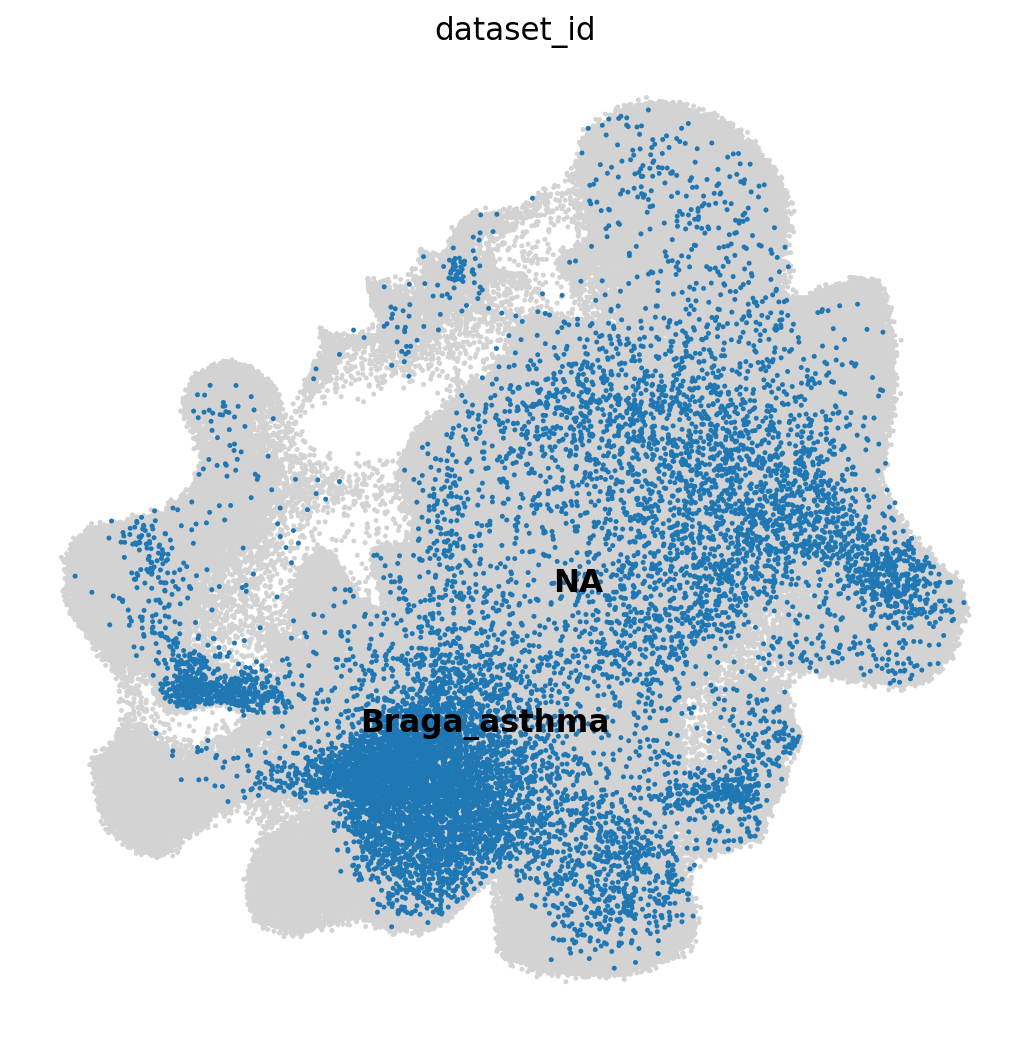

Skin_Reynolds_et_al


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


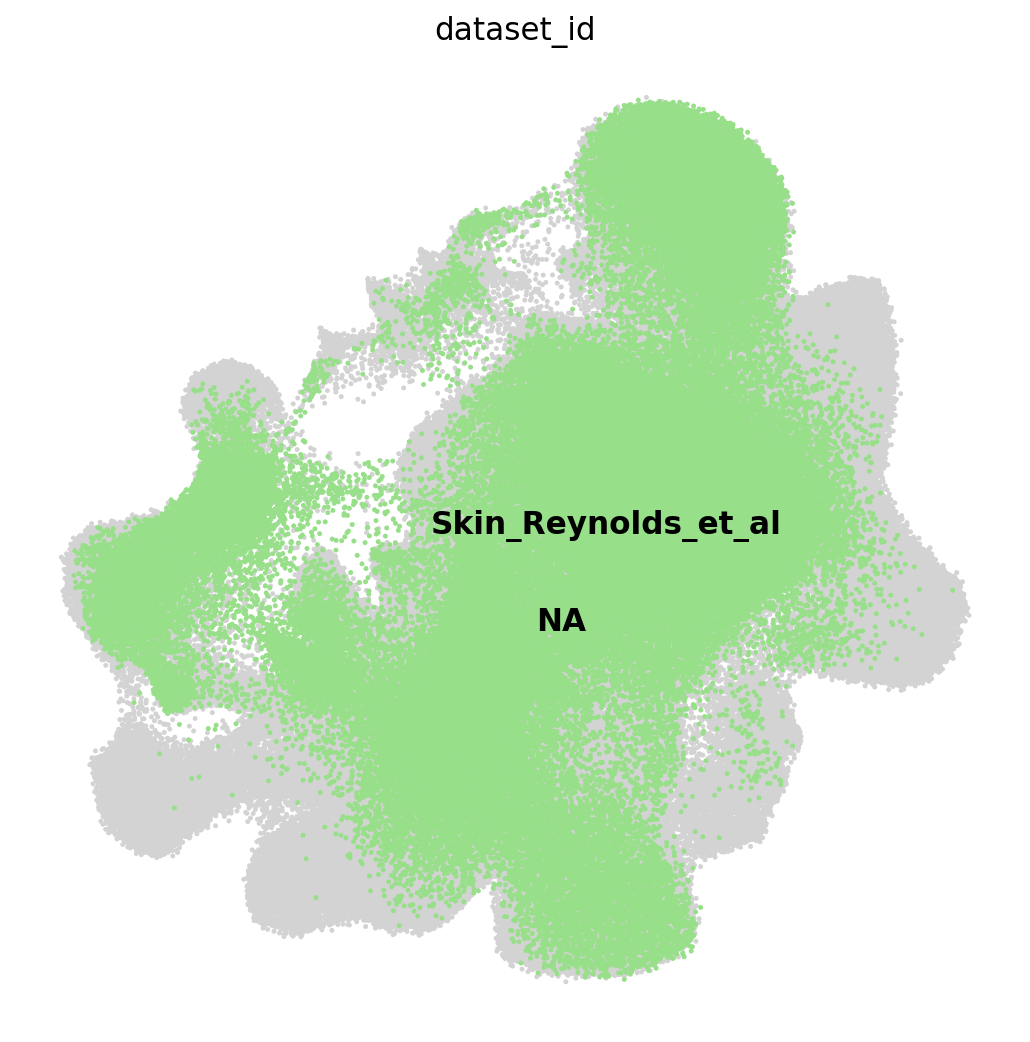

Qian_Yue_Zhang_2022


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


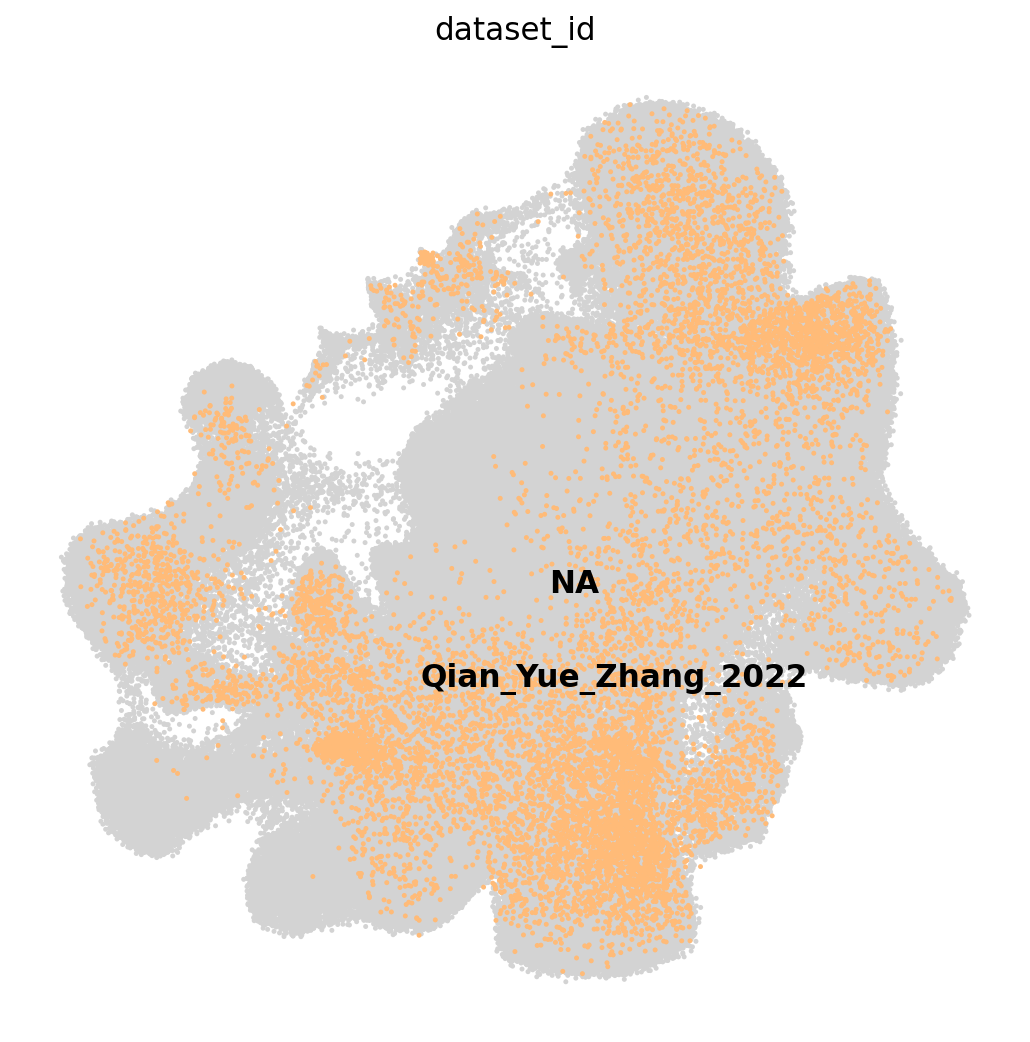

Martin_JIA_2019


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


In [ ]:
for dis in adata_full.obs.dataset_id.unique():
    print(dis)
    sc.pl.umap(
        adata_full,
        groups=dis,
        color=["dataset_id"],
        frameon=False,
        size=20,
        ncols=2,
        legend_loc="on data"
    )